# Generator de text caracter-cu-caracter cu LSTM

**Laborator Generative AI** — model antrenat pe ~1.4 milioane de caractere de literatură română.

Modelul primește un început de text și îl continuă, o literă pe rând. Nu înțelege ce scrie — prezice doar care caracter urmează, statistic. Repetat de 300 de ori, iese text.

Notebook-ul e interactiv: rulează celulele în ordine, apoi folosește butoanele și sliderele ca să experimentezi direct cu modelul.

---

## Cuprins

1. [Setup](#setup)
2. [Datele](#date)
3. [Arhitectura](#arhitectura)
4. [Hiperparametrii și costul lor real](#viteza)
5. [Antrenarea](#antrenare)
6. [Generare interactivă](#generare)
7. [Cum decide modelul, pas cu pas](#decizie)
8. [Strategii de alegere](#strategii)
9. [Progresia învățării](#progresie)
10. [Memorează sau compune?](#memorare)
11. [Concluzii](#concluzii)

<a id='setup'></a>
## 1. Setup

Încărcăm modelul deja antrenat. Prima rulare durează ~30 de secunde (TensorFlow pornește greu).

In [1]:
import time
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import ipywidgets as widgets
from IPython.display import display, clear_output
from tensorflow import keras

from charlstm import (
    CKPT_DIR, SEQ_LEN, STRIDE, BATCH_SIZE, EMBED_DIM, LSTM_UNITS,
    EPOCHS, STEPS_PER_EPOCH, LEARNING_RATE,
    load_and_normalize, load_vocab, generate, pick_next,
)

plt.style.use("seaborn-v0_8-whitegrid")

corpus = load_and_normalize()
char_to_idx, idx_to_char = load_vocab()
model = keras.models.load_model(CKPT_DIR / "final.keras")

print(f"Model încărcat: {model.count_params():,} parametri")
print(f"Corpus: {len(corpus):,} caractere | vocabular: {len(char_to_idx)} caractere unice")

Model încărcat: 364,656 parametri
Corpus: 1,385,564 caractere | vocabular: 112 caractere unice


<a id='date'></a>
## 2. Datele

Corpusul e text brut. Modelul nu primește nicio adnotare — nici unde se termină cuvintele, nici ce e un vers, nici cine vorbește.

In [2]:
print(corpus[:300])
print("\n" + "─" * 60)
print(f"Caractere totale:  {len(corpus):,}")
print(f"Caractere unice:   {len(char_to_idx)}")
print(f"Linii:             {corpus.count(chr(10)):,}")

Adio

De-acuma nu te-oi mai vedea,
Rămâi, rămâi, cu bine!
Mă voi feri în calea mea
De tine.

De astăzi dar tu fă ce vrei,
De astăzi nu-mi mai pasă
Că cea mai dulce-ntre femei
Mă lasă.

Căci nu mai am de obicei
Ca-n zilele acele,
Să mă îmbăt și de scântei
Din stele,

Când degerând atâtea dăți,
Eu mă 

────────────────────────────────────────────────────────────
Caractere totale:  1,385,564
Caractere unice:   112
Linii:             42,339


### Vocabularul

Fiecare caracter unic primește un număr. Modelul lucrează doar cu numere — literele sunt traduse la intrare și înapoi la ieșire.

**De ce pe caractere și nu pe cuvinte:** un model pe cuvinte are o listă fixă (să zicem 50.000 de cuvinte). Orice cuvânt din afara listei — un nume, o poreclă, o greșeală de tipar — e complet inaccesibil. Se numește problema *out-of-vocabulary*. Cu 112 caractere poți scrie orice cuvânt care a existat sau va exista vreodată.

In [3]:
vocab_display = "".join(
    c if c not in "\n\t" else {"\n": "⏎", "\t": "⇥"}[c]
    for c in sorted(char_to_idx)
)
print("Vocabularul complet:")
print(vocab_display)

print("\nExemplu de codificare:")
exemplu = "Adio"
print(f"  text:   {exemplu}")
print(f"  numere: {[char_to_idx[c] for c in exemplu]}")

Vocabularul complet:
⏎ !"'()*+,-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZ[]abcdefghijklmnopqrstuvwxyz«·»ÂÉÎàáâçèéêìíîöùúüĂăęĭůȘșȚț—„…

Exemplu de codificare:
  text:   Adio
  numere: [26, 57, 62, 68]


### Un detaliu care strică totul dacă e ratat: normalizarea Unicode

Litera `ș` poate ajunge în fișier în **trei** feluri care arată aproape identic pe ecran:

| formă | codepoint(uri) | corect pentru română? |
|---|---|---|
| `ș` precompus | U+0219 | da |
| `s` + virgulă combinată | U+0073 U+0326 | da, dar două caractere |
| `ş` cu cedilă | U+015F | **nu** — e litera turcească |

Pentru model, fiecare variantă e o literă complet diferită. Fără normalizare, vocabularul s-ar umple cu duplicate și statistica s-ar împărți între ele.

`unicodedata.normalize("NFC", text)` unește primele două (lipește virgula de literă). **Nu rezolvă a treia** — cedila e alt caracter, nu o variantă de scriere, deci ar rămâne separată în vocabular.

Celula de mai jos verifică ambele cazuri și numără ce se găsește în corpusul nostru.

In [4]:
precompus = chr(0x0219)          # ș — un caracter: s cu VIRGULĂ dedesubt
descompus = "s" + chr(0x0326)    # s + virgulă combinată — două caractere
cedila    = chr(0x015F)          # ş — s cu CEDILĂ, alt caracter (turcesc)

print(f"Arată similar:   '{precompus}'   '{descompus}'   '{cedila}'")
print(f"Lungimi:          {len(precompus)}     {len(descompus)}     {len(cedila)}\n")

nfc = lambda s: unicodedata.normalize("NFC", s)

print(f"precompus == descompus, brut?      {precompus == descompus}")
print(f"precompus == descompus, după NFC?  {nfc(precompus) == nfc(descompus)}   ← NFC rezolvă")
print(f"precompus == cedilă,    după NFC?  {nfc(precompus) == nfc(cedila)}   ← NFC NU rezolvă\n")

print("Cât de curat e corpusul nostru (după normalizare NFC):")
for nume, cod in [("ș cu virgulă  (corect)", 0x0219), ("ş cu cedilă  (greșit)", 0x015F),
                  ("ț cu virgulă  (corect)", 0x021B), ("ţ cu cedilă  (greșit)", 0x0163)]:
    print(f"  {nume:26} {corpus.count(chr(cod)):>7,}")

Arată similar:   'ș'   'ș'   'ş'
Lungimi:          1     2     1

precompus == descompus, brut?      False
precompus == descompus, după NFC?  True   ← NFC rezolvă
precompus == cedilă,    după NFC?  False   ← NFC NU rezolvă

Cât de curat e corpusul nostru (după normalizare NFC):
  ș cu virgulă  (corect)      14,440
  ş cu cedilă  (greșit)            0
  ț cu virgulă  (corect)      10,078
  ţ cu cedilă  (greșit)            0


<a id='arhitectura'></a>
## 3. Arhitectura

Trei straturi. Fluxul: număr → vector → memorie → scoruri pentru fiecare literă posibilă.

```
  "Adio"  →  [0, 61, 51, 65]           codificare
               ↓
         Embedding (64 numere/literă)   ce înseamnă litera asta
               ↓
         LSTM (256 unități)             memoria de lucru
               ↓
         Dense (112 ieșiri)             scor pentru fiecare literă posibilă
               ↓
         softmax → probabilități        [2%, 31%, 0.4%, ...]
```

In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 64)       │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, None, 256)      │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 112)      │        28,784 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,093,970 (4.17 MB)

 Trainable params: 364,656 (1.39 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 729,314 (2.78 MB)

### Ce face fiecare strat

**Embedding** — traduce fiecare literă într-un vector de 64 de numere pe care modelul le învață singur. Literele folosite în contexte similare (vocalele, de exemplu) ajung să aibă vectori asemănători. Nimeni nu i-a spus ce e o vocală.

**LSTM** — memoria de lucru. 256 de numere care se actualizează după fiecare literă și rezumă tot ce s-a citit până atunci.

> Analogie: citești o carte și cineva te întreabă ce urmează. Nu te uiți doar la ultimul cuvânt — ai în cap cine sunt personajele, unde sunt, ce tocmai s-a zis. Dar nu ții minte fiecare cuvânt, ci un rezumat. Hidden state e rezumatul ăla.

Important: rămâne **mereu 256 de numere**, fie că ai citit 10 litere sau 10.000. Ce nu încape se pierde — de-asta modelul uită începutul propoziției.

**Dense** — transformă memoria în 112 scoruri, câte unul pentru fiecare literă posibilă.

<a id='viteza'></a>
## 4. Hiperparametrii și costul lor real

Înainte de antrenare am **măsurat** cât costă fiecare configurație pe acest procesor (fără placă video). Numerele de mai jos vin din rulare reală ([probe.py](probe.py)), nu din estimări.

In [6]:
masuratori = pd.DataFrame([
    {"unități": 128, "batch": 128, "seq_len": 100, "parametri": 120_432,
     "sec/pas": 0.153, "caractere/sec": 83_647},
    {"unități": 256, "batch": 128, "seq_len": 100, "parametri": 364_656,
     "sec/pas": 0.468, "caractere/sec": 27_322},
    {"unități": 256, "batch": 256, "seq_len": 100, "parametri": 364_656,
     "sec/pas": 0.716, "caractere/sec": 35_730},
    {"unități": 256, "batch": 128, "seq_len": 50, "parametri": 364_656,
     "sec/pas": 0.305, "caractere/sec": 20_978},
    {"unități": 512, "batch": 128, "seq_len": 100, "parametri": 1_246_320,
     "sec/pas": 0.904, "caractere/sec": 14_166},
])

display(masuratori.style.hide(axis="index").format({
    "parametri": "{:,}", "sec/pas": "{:.3f}", "caractere/sec": "{:,}"
}).background_gradient(subset=["caractere/sec"], cmap="RdYlGn"))

unități,batch,seq_len,parametri,sec/pas,caractere/sec
128,128,100,"120,432",0.153,"83,647"
256,128,100,"364,656",0.468,"27,322"
256,256,100,"364,656",0.716,"35,730"
256,128,50,"364,656",0.305,"20,978"
512,128,100,"1,246,320",0.904,"14,166"


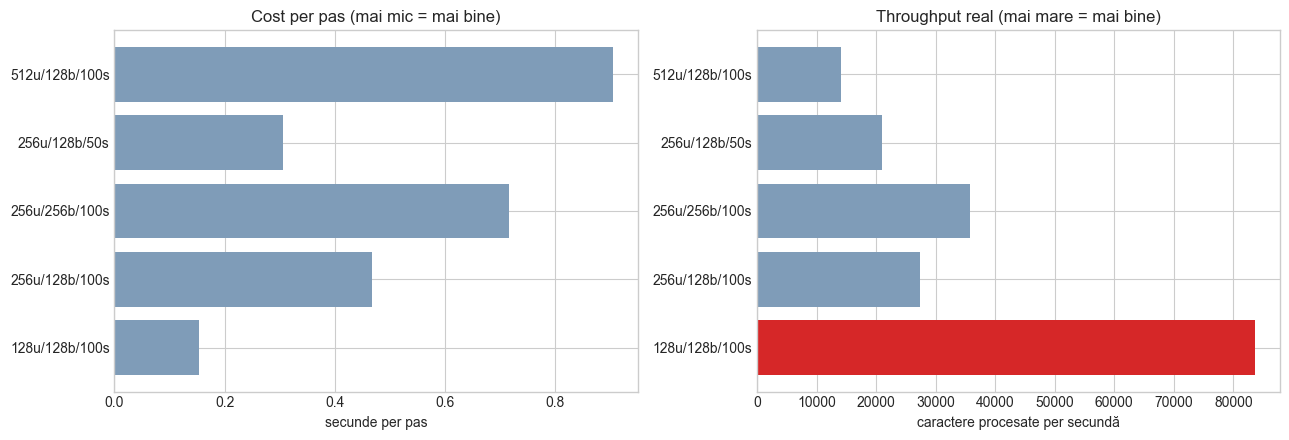

Capcana: configurația cu cel mai mic sec/pas NU e cea mai rapidă per caracter.
batch=256 costă mai mult per pas (0.716 vs 0.468) dar procesează cu 31% mai
multe caractere pe secundă, pentru că face mai multă treabă la fiecare pas.


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

etichete = [f"{r.unități}u/{r.batch}b/{r.seq_len}s" for r in masuratori.itertuples()]
culori = ["#d62728" if c == masuratori["caractere/sec"].max() else "#7f9cb8"
          for c in masuratori["caractere/sec"]]

ax1.barh(etichete, masuratori["sec/pas"], color="#7f9cb8")
ax1.set_xlabel("secunde per pas")
ax1.set_title("Cost per pas (mai mic = mai bine)")

ax2.barh(etichete, masuratori["caractere/sec"], color=culori)
ax2.set_xlabel("caractere procesate per secundă")
ax2.set_title("Throughput real (mai mare = mai bine)")

plt.tight_layout()
plt.show()

print("Capcana: configurația cu cel mai mic sec/pas NU e cea mai rapidă per caracter.")
print("batch=256 costă mai mult per pas (0.716 vs 0.468) dar procesează cu 31% mai")
print("multe caractere pe secundă, pentru că face mai multă treabă la fiecare pas.")

### Ce înseamnă fiecare buton

| parametru | valoare | ce face | efect dacă crești |
|---|---|---|---|
| `SEQ_LEN` | 100 | câte litere vede înainte să prezică | context mai bun, cost liniar |
| `LSTM_UNITS` | 256 | mărimea memoriei de lucru | 512 → **3.1x** mai lent |
| `BATCH_SIZE` | 256 | câte exemple odată | throughput mai bun, mai puține corecții |
| `EMBED_DIM` | 64 | câte numere descriu o literă | impact mic |
| `STRIDE` | 5 | suprapunerea exemplelor | mai mare = epocă mai rapidă |
| `EPOCHS` | 20 | runde de antrenare | liniar în timp |
| `LEARNING_RATE` | 0.002 | mărimea corecțiilor | prea mare = instabil |

**`temperature` e singurul care nu cere reantrenare** — se schimbă la generare, costă zero.

In [8]:
print("Configurația folosită la antrenare:\n")
for nume, val in [
    ("SEQ_LEN", SEQ_LEN), ("STRIDE", STRIDE), ("BATCH_SIZE", BATCH_SIZE),
    ("EMBED_DIM", EMBED_DIM), ("LSTM_UNITS", LSTM_UNITS),
    ("EPOCHS", EPOCHS), ("STEPS_PER_EPOCH", STEPS_PER_EPOCH),
    ("LEARNING_RATE", LEARNING_RATE),
]:
    print(f"  {nume:<18} {val}")

ferestre = (len(corpus) - SEQ_LEN - 1) // STRIDE
esantioane = STEPS_PER_EPOCH * BATCH_SIZE
print(f"\nFerestre de antrenare: {ferestre:,}")
print(f"Eșantioane per epocă:  {esantioane:,} ({esantioane/ferestre:.1%} din date)")
print(f"Treceri reale prin corpus după {EPOCHS} epoci: {EPOCHS*esantioane/ferestre:.2f}")
print("\nNotă: o «epocă» aici e o unitate de checkpoint, nu o trecere completă.")

Configurația folosită la antrenare:

  SEQ_LEN            100
  STRIDE             5
  BATCH_SIZE         256
  EMBED_DIM          64
  LSTM_UNITS         256
  EPOCHS             20
  STEPS_PER_EPOCH    250
  LEARNING_RATE      0.002

Ferestre de antrenare: 277,092
Eșantioane per epocă:  64,000 (23.1% din date)
Treceri reale prin corpus după 20 epoci: 4.62

Notă: o «epocă» aici e o unitate de checkpoint, nu o trecere completă.


<a id='antrenare'></a>
## 5. Antrenarea

47.3 minute pe procesor. Loss-ul măsoară cât de greșit prezice modelul — mai mic e mai bun.

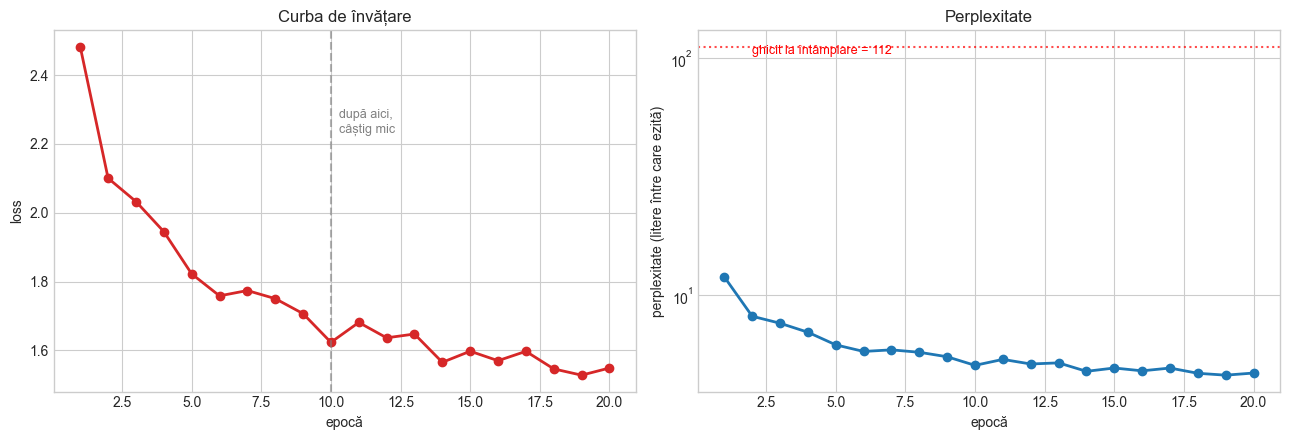

Loss:  2.482 → 1.549
Perplexitate finală: 4.7

Modelul ezită efectiv între ~5 litere
la fiecare pas, în loc de 112 dacă ar ghici la întâmplare.


In [9]:
istoric = pd.read_csv(CKPT_DIR / "history.csv")
istoric["epoca"] = istoric["epoch"] + 1
istoric["perplexitate"] = np.exp(istoric["loss"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(istoric["epoca"], istoric["loss"], marker="o", color="#d62728", lw=2)
ax1.axvline(10, ls="--", color="gray", alpha=0.6)
ax1.text(10.3, istoric["loss"].max() * 0.9, "după aici,\ncâștig mic",
         fontsize=9, color="gray")
ax1.set_xlabel("epocă")
ax1.set_ylabel("loss")
ax1.set_title("Curba de învățare")

ax2.plot(istoric["epoca"], istoric["perplexitate"], marker="o", color="#1f77b4", lw=2)
ax2.axhline(len(char_to_idx), ls=":", color="red", alpha=0.7)
ax2.text(2, len(char_to_idx) * 0.93, f"ghicit la întâmplare = {len(char_to_idx)}",
         fontsize=9, color="red")
ax2.set_xlabel("epocă")
ax2.set_ylabel("perplexitate (litere între care ezită)")
ax2.set_title("Perplexitate")
ax2.set_yscale("log")

plt.tight_layout()
plt.show()

print(f"Loss:  {istoric['loss'].iloc[0]:.3f} → {istoric['loss'].iloc[-1]:.3f}")
print(f"Perplexitate finală: {np.exp(istoric['loss'].iloc[-1]):.1f}")
print(f"\nModelul ezită efectiv între ~{np.exp(istoric['loss'].iloc[-1]):.0f} litere")
print(f"la fiecare pas, în loc de {len(char_to_idx)} dacă ar ghici la întâmplare.")

**Ce se vede:** coborâre rapidă până la epoca 10, apoi platou. Ultimele 10 epoci au adus doar 0.07 — motiv suficient să oprim la 20.

> Analogie: înveți la un examen. Prima citire prinzi ideea. A doua, detalii. A cincea — nu mai câștigi mare lucru.

<a id='generare'></a>
## 6. Generare interactivă

Scrie un început de text, apasă butonul. Modelul continuă literă cu literă, în timp real.

**Ce merită încercat:** `ARVINTE:` (nume de personaj), `SCENA` (structură de piesă), sau numele tău — modelul continuă orice, fiindcă lucrează pe litere.

In [10]:
def genereaza_live(seed, n_chars, temperature, strategy, delay, out):
    """Generează caracter cu caracter, afișând pe măsură ce scrie."""
    seed_norm = unicodedata.normalize("NFC", seed)
    context = [char_to_idx[c] for c in seed_norm if c in char_to_idx]

    if not context:
        with out:
            print("Niciun caracter din seed nu e în vocabular.")
        return

    text, sanse, sigur = seed_norm, [], 0

    for _ in range(n_chars):
        logits = model(tf.constant([context[-SEQ_LEN:]], dtype=tf.int32), training=False)
        probs = tf.nn.softmax(logits[0, -1] / temperature).numpy().astype(np.float64)
        probs /= probs.sum()

        if probs.max() >= 0.5:
            sigur += 1

        ales = pick_next(probs, strategy)
        context.append(ales)
        text += idx_to_char[ales]
        sanse.append(round(float(probs[ales]) * 100))

        with out:
            clear_output(wait=True)
            print(text)
        if delay:
            time.sleep(delay)

    with out:
        clear_output(wait=True)
        print(text)
        print(f"\n{'─' * 60}")
        print(f"șanse per literă: {sanse}")
        print(f"medie: {np.mean(sanse):.0f}%  |  min: {min(sanse)}%  |  max: {max(sanse)}%")
        print(f"peste 50%: {sigur}/{n_chars} pași ({sigur/n_chars:.0%})")


w_seed = widgets.Text(value="ARVINTE: Ce ", description="Început:",
                      layout=widgets.Layout(width="500px"),
                      style={"description_width": "90px"})
w_n = widgets.IntSlider(value=60, min=10, max=300, step=10, description="Caractere:",
                        style={"description_width": "90px"})
w_temp = widgets.FloatSlider(value=0.8, min=0.1, max=2.0, step=0.1,
                             description="Temperature:", style={"description_width": "90px"})
w_strat = widgets.Dropdown(options=["sample", "confident", "argmax"], value="sample",
                           description="Strategie:", style={"description_width": "90px"})
w_delay = widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.1,
                              description="Pauză (s):", style={"description_width": "90px"})
w_buton = widgets.Button(description="Generează", button_style="primary", icon="play")
w_out = widgets.Output(layout=widgets.Layout(border="1px solid #ddd", padding="10px",
                                             min_height="160px"))

def la_click(_):
    w_buton.disabled = True
    w_buton.description = "Generez..."
    try:
        with w_out:
            clear_output()
        genereaza_live(w_seed.value, w_n.value, w_temp.value,
                       w_strat.value, w_delay.value, w_out)
    finally:
        w_buton.disabled = False
        w_buton.description = "Generează"

w_buton.on_click(la_click)

display(widgets.VBox([w_seed, w_n, w_temp, w_strat, w_delay, w_buton, w_out]))

### Temperature: singurul buton care nu costă nimic

Controlează cât de riscant alege modelul. Rulează celula ca să vezi aceeași sămânță la patru temperaturi.

> Analogie: karaoke. Temperatură mică = cânți exact melodia, sigur dar plictisitor. Temperatură mare = improvizezi, uneori genial, de obicei fals.

In [14]:
for temp in (0.2, 0.5, 0.8, 1.3):
    text = generate(model, "Adio\n\n", char_to_idx, idx_to_char,
                    n_chars=180, temperature=temp)
    print(f"{'═' * 65}\n  temperature = {temp}\n{'═' * 65}")
    print(text) #text.replace("\n", " ⏎ ")
    print()

═════════════════════════════════════════════════════════════════
  temperature = 0.2
═════════════════════════════════════════════════════════════════
Adio

SCENA III
ARVINTE: Ce să ne pune să mă duc de antereu cu parcă să mă cuprins de la masă de antereu să mă chemat cu mine să mă cheamă cu mine să fie de mănăstire cu antereu cu mine 

═════════════════════════════════════════════════════════════════
  temperature = 0.5
═════════════════════════════════════════════════════════════════
Adio

SCENA III
ARVINTE (viind cu mândrie!
Acea fi răspunde, mai mare,
Cerc de pe păcat în coarne
Cu antelie se putea,
Dar ce crească cu chin mine
Pe mine s-a dus,
Adio el în parte): Pe 

═════════════════════════════════════════════════════════════════
  temperature = 0.8
═════════════════════════════════════════════════════════════════
Adio

Povestea cum ascunde curte.
Vezi, trăiască-i fericire,
Plin de-atunci în aceasta, poet voiesc.
Ia-mea cuima de focul loc
De când te furgul ce e tic
Auchia slăvit,

**De urmărit:**
- **0.2** — se blochează în bucle (`în care mi-a pus` repetat). Distribuția e prea ascuțită.
- **0.8** — cuvinte reale, variație bună. Punctul dulce.
- **1.3** — inventează cuvinte cu statistică românească corectă, dar fără sens.

<a id='decizie'></a>
## 7. Cum decide modelul, pas cu pas

Partea cea mai importantă din tot notebook-ul. La fiecare literă, modelul **nu alege una singură** — calculează probabilități pentru toate cele 112 și trage la sorți.

Graficul de mai jos arată, pentru fiecare pas, primii 5 candidați și care a fost ales.

C:\Users\User\AppData\Local\Temp\ipykernel_1520\3184635381.py:39: UserWarning: Glyph 9251 (\N{OPEN BOX}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 9251 (\N{OPEN BOX}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


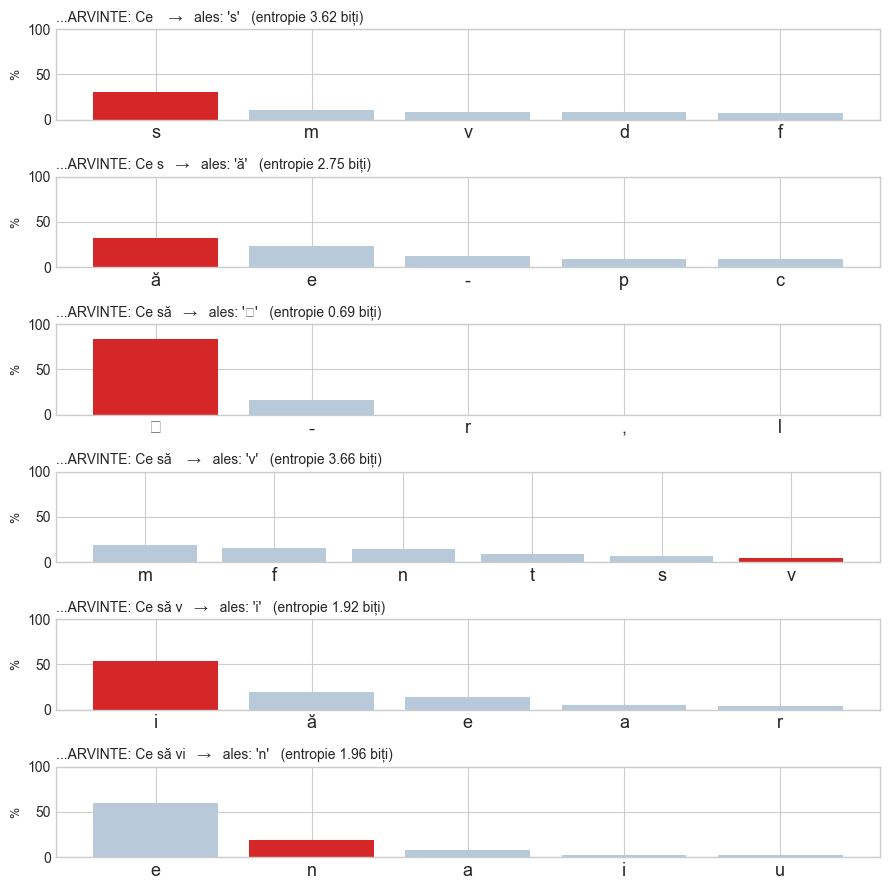

Roșu = ales.  Entropie mică = modelul e sigur.  Mare = ezită.


In [15]:
def arata_char(c):
    return {"\n": "⏎", " ": "␣", "\t": "⇥"}.get(c, c)


def pas_cu_pas(seed="ARVINTE: Ce ", n_pasi=6, temperature=0.8, strategy="sample"):
    context = [char_to_idx[c] for c in unicodedata.normalize("NFC", seed)
               if c in char_to_idx]
    fig, axes = plt.subplots(n_pasi, 1, figsize=(9, 1.5 * n_pasi))
    if n_pasi == 1:
        axes = [axes]

    for ax in axes:
        logits = model(tf.constant([context[-SEQ_LEN:]], dtype=tf.int32), training=False)
        probs = tf.nn.softmax(logits[0, -1] / temperature).numpy().astype(np.float64)
        probs /= probs.sum()

        ales = pick_next(probs, strategy)
        top = np.argsort(probs)[::-1][:5]
        if ales not in top:
            top = np.append(top, ales)

        entropie = -np.sum(probs * np.log2(probs + 1e-12))
        etichete = [arata_char(idx_to_char[i]) for i in top]
        culori = ["#d62728" if i == ales else "#b8c9d9" for i in top]

        ax.bar(range(len(top)), probs[top] * 100, color=culori)
        ax.set_xticks(range(len(top)))
        ax.set_xticklabels(etichete, fontsize=13)
        ax.set_ylabel("%", fontsize=9)
        ax.set_ylim(0, max(100, probs[top].max() * 105))

        ctx = "".join(idx_to_char[i] for i in context[-22:]).replace("\n", "⏎")
        ax.set_title(f"...{ctx}   →   ales: '{arata_char(idx_to_char[ales])}'"
                     f"   (entropie {entropie:.2f} biți)",
                     fontsize=10, loc="left")

        context.append(ales)

    plt.tight_layout()
    plt.show()
    print("Roșu = ales.  Entropie mică = modelul e sigur.  Mare = ezită.")


pas_cu_pas()

### Ce arată graficele

**Entropia variază mult de la pas la pas.** Măsoară incertitudinea în biți:
- **entropie mică** (~1 bit) — modelul e aproape sigur. Se întâmplă după terminații de cuvânt: știe că urmează spațiu.
- **entropie mare** (~4 biți) — început de cuvânt nou, poate urma orice literă.

Modelul a învățat **unde se termină cuvintele** fără ca nimeni să-i spună ce e un cuvânt.

**Uneori alege din afara top 5.** Dovadă directă că e eșantionare, nu `argmax`. Dacă lua mereu maximul, ar fi ales mereu bara cea mai înaltă.

<a id='strategii'></a>
## 8. Strategii de alegere

Trei feluri de a alege litera următoare din aceeași distribuție:

| strategie | regulă | rezultat |
|---|---|---|
| `argmax` | mereu cea mai probabilă | determinist, **intră în bucle** |
| `sample` | trage la sorți proporțional | divers, uneori aiurea |
| `confident` | peste 50% o ia direct, altfel din top 5 | compromis |

In [17]:
for strat in ("argmax", "confident", "sample"):
    text = generate(model, "ARVINTE: Ce ", char_to_idx, idx_to_char,
                    n_chars=140, temperature=0.8, strategy=strat)
    print(f"{'═' * 65}\n  {strat}\n{'═' * 65}")
    print(text) #text.replace("\n", " ⏎ ")
    print()

═════════════════════════════════════════════════════════════════
  argmax
═════════════════════════════════════════════════════════════════
ARVINTE: Ce să mă cheamă cu care se întoarce cu mine să fie care se întoarce cu mine să fie care se întoarce cu mine să fie care se întoarce cu mine să 

═════════════════════════════════════════════════════════════════
  confident
═════════════════════════════════════════════════════════════════
ARVINTE: Ce se întreabă cu ceruri de antereu că a fost să vie la casa ce mă cunosc pe care mi-a pus în casă, în comistocată de ce mă culcă de păretele m

═════════════════════════════════════════════════════════════════
  sample
═════════════════════════════════════════════════════════════════
ARVINTE: Ce poți în ceruți pe povastă românească nori îna cine la mine!
MATILDA: Ce de vine moarte, că e m-a depărtat - de mări din ore deschisă din urm



**`argmax` e demonstrația de ce eșantionarea e necesară.** Modelul ajunge într-o stare, alege litera cea mai probabilă, ajunge în aceeași stare, alege aceeași literă. Ciclu închis, la infinit.

> Analogie: Spotify shuffle. Dacă ar pune mereu melodia ta preferată, ai asculta aceeași piesă la nesfârșit.

<a id='progresie'></a>
## 9. Progresia învățării

Același început de text, generat din checkpoint-uri de la momente diferite ale antrenării. Se vede exact ce a învățat și când.

*(Durează ~1 minut — încarcă trei modele.)*

In [19]:
checkpoints = sorted(CKPT_DIR.glob("epoch_*.keras"))
alese = [checkpoints[0], checkpoints[len(checkpoints) // 2], checkpoints[-1]]

for ckpt in alese:
    m = keras.models.load_model(ckpt)
    text = generate(m, "Adio\n\n", char_to_idx, idx_to_char,
                    n_chars=200, temperature=0.8)
    loss = istoric.loc[istoric["epoca"] == int(ckpt.stem.split("_")[1]), "loss"]
    eticheta = f"{ckpt.stem}  (loss {loss.iloc[0]:.3f})" if len(loss) else ckpt.stem
    print(f"{'═' * 65}\n  {eticheta}\n{'═' * 65}")
    print(text) #text.replace("\n", " ⏎ ")
    print()

═════════════════════════════════════════════════════════════════
  epoch_01  (loss 2.482)
═════════════════════════════════════════════════════════════════
Adio

Deșt ophis osfledare, Dare mânduni
Ce ce viel de porul.

Încurt cum comunt!
Api alvăsatere cânde de bare-l feară
Și cradu luptă tre ture
Să-l cum. "Dai du numpii însă rânte oc mărite mâns
Pe pinere pe

═════════════════════════════════════════════════════════════════
  epoch_11  (loss 1.681)
═════════════════════════════════════════════════════════════════
Adio

Că ți-am fost acepturat singur.
AGACHI: Cătră-n cale-n sfîrzită de eu lupta.
COȘCODAN (Iesă; nu ani;
A două para nu mai bine!
Cucînd cu jocul din feci.
COȘCODAN (Statorul din mort ființi?
AGACHI: Domn

═════════════════════════════════════════════════════════════════
  epoch_20  (loss 1.549)
═════════════════════════════════════════════════════════════════
Adio

COȘCODAN: La pază): Măndică! mai știu celei, se măndică!... Însă nu se duc pe tine, română, fără sfârșit, s

**Progresia observată:**

| moment | ce a învățat |
|---|---|
| epoca 1 | lungimea cuvintelor, spații, versuri scurte — dar cuvintele nu există |
| epoca 11 | personaje, structură de dialog, cuvinte parțial reale |
| epoca 20 | cuvinte majoritar reale, morfologie românească, sintaxă aproape corectă |

### Descoperirea neașteptată

Corpusul conține comedii de Alecsandri, iar modelul a dedus **formatul de piesă de teatru** din statistica literelor:

```
SCENA VI
COȘCODAN, BARZĂ, zic: Ce-ai puș, îmi scoseau vesel închis
ARVINTE: Fețe, frace stînca cucrumul
```

A învățat că după `SCENA` vine cifră romană, că un nume cu majuscule e urmat de două puncte, și că apoi urmează replica. Nicio regulă scrisă — doar statistică pe caractere.

<a id='memorare'></a>
## 10. Memorează sau compune?

Cea mai probabilă întrebare critică. Verificare directă: căutăm cea mai lungă secvență generată care apare **cuvânt cu cuvânt** în corpus.

In [20]:
def cea_mai_lunga_copiata(generat, corpus, max_n=60):
    """Căutare binară pe lungime: cea mai lungă bucată comună."""
    def exista(n):
        return any(generat[i:i + n] in corpus for i in range(len(generat) - n + 1))

    lo, hi = 0, min(max_n, len(generat))
    while lo < hi:
        mid = (lo + hi + 1) // 2
        if exista(mid):
            lo = mid
        else:
            hi = mid - 1
    return lo


generat = generate(model, "Adio\n\n", char_to_idx, idx_to_char,
                   n_chars=1000, temperature=0.8)
n = cea_mai_lunga_copiata(generat, corpus)

print(f"Cea mai lungă secvență copiată verbatim: {n} caractere (din 1000 generate)")
print("→ scurt: modelul compune, nu copiază.\n")
print(f"Corpus:  {len(corpus):,} caractere")
print(f"Model:   {model.count_params():,} parametri (~1.4 MB pe disc)")
print("\nTextul pur și simplu NU încape în model. Nu e stocat — e rezumat.")

Cea mai lungă secvență copiată verbatim: 21 caractere (din 1000 generate)
→ scurt: modelul compune, nu copiază.

Corpus:  1,385,564 caractere
Model:   364,656 parametri (~1.4 MB pe disc)

Textul pur și simplu NU încape în model. Nu e stocat — e rezumat.


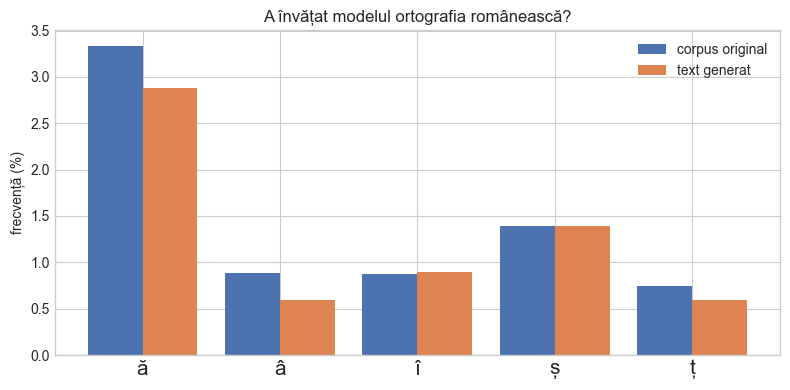

,generat %,corpus %,raport
ă,2.883,3.335,0.864
â,0.596,0.880,0.678
î,0.895,0.870,1.029
ș,1.392,1.390,1.001
ț,0.596,0.744,0.802


Raport 1.00 = frecvență identică cu originalul.


In [21]:
DIACRITICE = "ăâîșț"

def distributie(text):
    n = Counter(text.lower())
    return {c: 100 * n[c] / len(text) for c in DIACRITICE}

gen_d, corp_d = distributie(generat), distributie(corpus)
tabel = pd.DataFrame({
    "generat %": [gen_d[c] for c in DIACRITICE],
    "corpus %": [corp_d[c] for c in DIACRITICE],
    "raport": [gen_d[c] / corp_d[c] if corp_d[c] else np.nan for c in DIACRITICE],
}, index=list(DIACRITICE))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(DIACRITICE))
ax.bar(x - 0.2, tabel["corpus %"], 0.4, label="corpus original", color="#4c72b0")
ax.bar(x + 0.2, tabel["generat %"], 0.4, label="text generat", color="#dd8452")
ax.set_xticks(x)
ax.set_xticklabels(list(DIACRITICE), fontsize=15)
ax.set_ylabel("frecvență (%)")
ax.set_title("A învățat modelul ortografia românească?")
ax.legend()
plt.tight_layout()
plt.show()

display(tabel.style.format("{:.3f}").background_gradient(subset=["raport"], cmap="RdYlGn",
                                                          vmin=0.5, vmax=1.5))
print("Raport 1.00 = frecvență identică cu originalul.")

**Cuvinte inventate găsite în texte generate:** „protrec", „mnăvieți", „blâjăve", „cucrumul".

Nu există în română, deci n-aveau cum să fie în corpus. Compuse din statistica literelor — dovadă că modelul generalizează, nu memorează.

<a id='concluzii'></a>
## 11. Concluzii

### Ce a învățat modelul

Fără nicio regulă scrisă, doar din statistica a 1.4 milioane de caractere:

- **ortografie** — cuvinte românești plauzibile, diacritice aproape la frecvența corectă
- **morfologie** — terminații, forme verbale, acorduri parțiale
- **structură** — versuri, dialog, format de piesă de teatru (`SCENA III`, `PERSONAJ:`)
- **unde se termină cuvintele** — vizibil în entropia care scade la sfârșit de cuvânt

### Ce NU poate face

- **nu răspunde la întrebări** — nu știe ce e o întrebare, doar continuă textul
- **nu înțelege sensul** — zero semantică, doar statistică pe litere
- **uită repede** — context de ~100 de caractere, cam 15 cuvinte
- **nu învață lucruri noi** fără reantrenare completă

### Contextul mai larg

| model | parametri | raport |
|---|---|---|
| **acest char-LSTM** | 364.656 | 1x |
| GPT-2 small (2019) | 124.000.000 | 340x |
| modele actuale | sute de miliarde | ~1.000.000x |

E un instrument de studiu, nu o unealtă. Dar **mecanismul de bază e identic** cu al modelelor mari: prezici ce urmează, eșantionezi dintr-o distribuție, repeți. Temperature, sampling, context limitat — toate există și în LLM-urile moderne. Diferă doar scara și arhitectura (Transformer în loc de LSTM).

---

### Detalii tehnice rezolvate pe parcurs

1. **Normalizare NFC** — fără ea, `ș` ar fi ajuns două intrări diferite în vocabular
2. **Consola Windows** — `cp1252` nu poate afișa `Ț`; rezolvat cu wrapper UTF-8 pe stdout
3. **Test de generare înainte de antrenare** — un bug în bucla de sampling se vede în primul minut, nu după 47
4. **Checkpoint la fiecare epocă** — plasă de siguranță, plus materialul pentru secțiunea 9
5. **Măsurare înainte de alegere** — toți hiperparametrii vin din [probe.py](probe.py), nu din presupuneri

### Fișierele proiectului

| fișier | rol |
|---|---|
| [charlstm.py](charlstm.py) | date, model, antrenare, generare |
| [probe.py](probe.py) | măsurători de viteză |
| [evaluate.py](evaluate.py) | memorare, diacritice, progresie |
| [inspect_generation.py](inspect_generation.py) | decizii pas cu pas |
| [chat_live.py](chat_live.py) | chat în terminal |
| [README.md](README.md) | documentație |